In [1]:
import numpy as np
import mrcfile
import matplotlib.pyplot as plt

from cryosiam.transforms.array import RandomMaskedViews
from cryosiam.data_structure.dense_simsiam_config import load_dense_simsiam_config
from cryosiam.apps.dense_simsiam_pretraining.module import DenseSimSiamModule 

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [2]:
path = "/scratch/talks/cryosiam_experiments/dense_simsiam_pretraining/patches_0/image/sample_1_Vol_z0_y0_x0.mrc"

In [3]:
with mrcfile.open(path) as mrc:
    data = mrc.data
    print(data.shape)

(128, 128, 128)


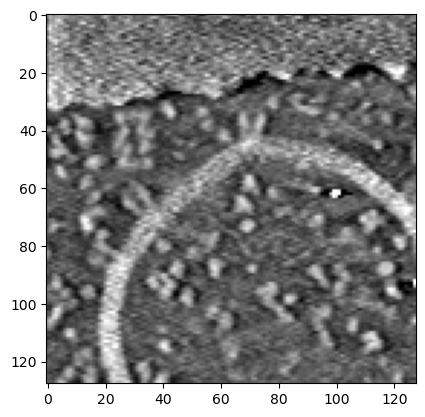

In [4]:
plt.imshow(data[100].squeeze(), cmap='gray')
plt.show()

In [5]:
id100_slice = data[100:101].copy()
print(id100_slice.shape)

(1, 128, 128)


In [6]:
views = RandomMaskedViews(
    input_image_size=(128, 128),
    view_size=(64,64),
    overlap=0.5,
    )(id100_slice)

In [7]:
views['view1'].shape, views['view2'].shape

((1, 64, 64), (1, 64, 64))

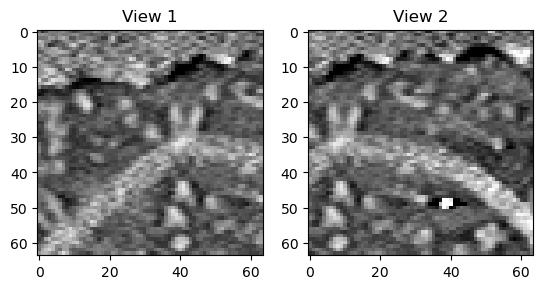

In [17]:
_, axs = plt.subplots(1, 2)
axs[0].imshow(views['view1'][0], cmap='gray')
axs[0].set_title('View 1')
axs[1].imshow(views['view2'][0], cmap='gray')
axs[1].set_title('View 2')
plt.show()

# View patches original

In [13]:
path = "/scratch/talks/data/simulated_datasets/experiments/new_models/dense_simsiam_heatmap/patches/image/sample_46_z0_y0_x0.mrc"

# Testing train_val split

In [2]:
config_path = "/g/kreshuk/talks/cryosiam/cryosiam/apps/dense_simsiam_pretraining/config.yaml"
cfg = load_dense_simsiam_config(config_path)

In [3]:
module = DenseSimSiamModule(cfg)

In [4]:
cfg.train_files

['sample_1_Vol.mrc', 'sample_2_Vol.mrc']

In [5]:
module.prepare_data()

In [7]:
import pickle

In [8]:
train_val_split_path = "/scratch/talks/cryosiam_experiments/dense_simsiam_pretraining/train_val_split.pkl"
with open(train_val_split_path, 'rb') as f:
    train_val_split = pickle.load(f)

In [9]:
print(len(train_val_split['train_files']))

128


In [10]:
len(train_val_split['val_files'])

128